# Machine Learning Layer of Project

Below, we have the formation of the dataframe from Q2 2026 Data

In [96]:
#pip install pandas
#pip install scipy
#pip install seaborn
#pip install jupyter
#pip install build
#pip install setuptools
#pip install wheel


In [97]:
import pandas as pd
import scipy as sp
import seaborn as sns
from matplotlib.layout_engine import PlaceHolderLayoutEngine


Loading the Data for Q2 2026 in Data Folder, doing some very basic EDA

In [98]:
import pandas as pd
#Import the sec data, put descriptions for each thing later, but all information is in the readme in the data folder
sub = pd.read_csv("data/sub.txt", sep="\t", header=0)
num = pd.read_csv("data/num.txt", sep="\t", header=0)
pre = pd.read_csv("data/pre.txt", sep="\t", header=0)
tag = pd.read_csv("data/tag.txt", sep="\t", header=0)

#Check the shape of each dataframe, also take a look at sub to see what's in there
display(sub)
print(sub.shape)
print(num.shape)
print(pre.shape)
print(tag.shape)

,adsh,cik,name,sic,countryba,stprba,cityba,zipba,bas1,bas2,...,period,fy,fp,filed,accepted,prevrpt,detail,instance,nciks,aciks
0,0000001961-26-000014,1961,GEMAXEL INC,7372.0,US,FL,MIAMI BEACH,33140,4775 COLLINS AVE,NaN,...,20250331.0,2025.0,Q1,20260605,2026-06-04 17:44:00.0,0,1,wddd10q125_htm.xml,1,NaN
1,0000001961-26-000025,1961,GEMAXEL INC,7372.0,US,FL,MIAMI BEACH,33140,4775 COLLINS AVE,NaN,...,20250630.0,2025.0,Q2,20260605,2026-06-05 16:45:00.0,0,1,wdddq22025_htm.xml,1,NaN
2,0000001961-26-000030,1961,GEMAXEL INC,7372.0,US,FL,MIAMI BEACH,33140,4775 COLLINS AVE,NaN,...,20250930.0,2025.0,Q3,20260605,2026-06-05 17:18:00.0,0,1,wdddq32025_htm.xml,1,NaN
3,0000002488-26-000076,2488,ADVANCED MICRO DEVICES INC,3674.0,US,CA,SANTA CLARA,95054,2485 AUGUSTINE DRIVE,NaN,...,20260331.0,2026.0,Q1,20260506,2026-05-05 18:06:00.0,0,1,amd-20260328_htm.xml,1,NaN
4,0000002969-26-000020,2969,"AIR PRODUCTS & CHEMICALS, INC.",2810.0,US,PA,ALLENTOWN,18106-5500,1940 AIR PRODUCTS BLVD.,NaN,...,20260331.0,2026.0,Q2,20260430,2026-04-30 11:07:00.0,0,1,apd-20260331_htm.xml,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7709,0002097163-26-000012,2097163,XANADU QUANTUM TECHNOLOGIES LTD,3571.0,NaN,NaN,TORONTO,M5G 2C8,"777 BAY STREET, SUITE 2400",NaN,...,20260331.0,2026.0,Q1,20260514,2026-05-14 16:07:00.0,0,1,xndu-20260331_htm.xml,1,NaN
7710,0002097953-26-000009,2097953,MIRA QON CORP,7374.0,US,MO,KANSAS CITY,64133,11312 E 44TH ST,NaN,...,20260228.0,2026.0,Q2,20260408,2026-04-08 11:25:00.0,0,1,mira10q02282026_htm.xml,1,NaN
7711,0002104052-26-000081,2104052,ENVIRI CORP,4953.0,US,PA,PHILADELPHIA,19103,TWO LOGAN SQUARE,"100-120 N. 18TH STREET, SUITE 1700",...,20260331.0,2026.0,Q1,20260608,2026-06-08 17:18:00.0,0,1,nvriwi-20260331_htm.xml,1,NaN
7712,0002104052-26-000118,2104052,ENVIRI CORP,4953.0,US,PA,PHILADELPHIA,19103,TWO LOGAN SQUARE,"100-120 N. 18TH STREET, SUITE 1700",...,20251231.0,NaN,NaN,20260618,2026-06-18 12:22:00.0,0,1,nvri-20260618_htm.xml,1,NaN


(7714, 36)
(3608711, 10)
(785490, 10)
(92731, 9)


In [99]:
#Check number of unique IDs, there are about 6 thousand for 2026 Q2
print(sub['cik'].nunique())

#See if there are any na values, sic, fy, fp have many NA values.
#Other columns with NA values are related to address
print(sub.isna().sum())

6179
adsh             0
cik              0
name             0
sic            190
countryba      582
stprba        1102
cityba           6
zipba          351
bas1             5
bas2          4178
baph             4
countryma      585
stprma        1079
cityma           7
zipma          347
mas1             6
mas2          4189
countryinc     674
stprinc       1728
ein              0
former        3307
changed       3307
afs             48
wksi             0
fye             16
form             0
period           1
fy             933
fp             951
filed            0
accepted         0
prevrpt          0
detail           0
instance         0
nciks            0
aciks         7583
dtype: int64


In [100]:
print(num.isna().sum())
#Sub and num are linked by accession number. We can see what we can access using both tables
#We can basically figure out the CIK and company name for a filing if we have the accession number
display(sub)
display(num)

adsh              0
tag               0
version           0
ddate             0
qtrs              0
uom               0
segments    1418876
coreg       3547589
value        179794
footnote    3499534
dtype: int64


,adsh,cik,name,sic,countryba,stprba,cityba,zipba,bas1,bas2,...,period,fy,fp,filed,accepted,prevrpt,detail,instance,nciks,aciks
0,0000001961-26-000014,1961,GEMAXEL INC,7372.0,US,FL,MIAMI BEACH,33140,4775 COLLINS AVE,NaN,...,20250331.0,2025.0,Q1,20260605,2026-06-04 17:44:00.0,0,1,wddd10q125_htm.xml,1,NaN
1,0000001961-26-000025,1961,GEMAXEL INC,7372.0,US,FL,MIAMI BEACH,33140,4775 COLLINS AVE,NaN,...,20250630.0,2025.0,Q2,20260605,2026-06-05 16:45:00.0,0,1,wdddq22025_htm.xml,1,NaN
2,0000001961-26-000030,1961,GEMAXEL INC,7372.0,US,FL,MIAMI BEACH,33140,4775 COLLINS AVE,NaN,...,20250930.0,2025.0,Q3,20260605,2026-06-05 17:18:00.0,0,1,wdddq32025_htm.xml,1,NaN
3,0000002488-26-000076,2488,ADVANCED MICRO DEVICES INC,3674.0,US,CA,SANTA CLARA,95054,2485 AUGUSTINE DRIVE,NaN,...,20260331.0,2026.0,Q1,20260506,2026-05-05 18:06:00.0,0,1,amd-20260328_htm.xml,1,NaN
4,0000002969-26-000020,2969,"AIR PRODUCTS & CHEMICALS, INC.",2810.0,US,PA,ALLENTOWN,18106-5500,1940 AIR PRODUCTS BLVD.,NaN,...,20260331.0,2026.0,Q2,20260430,2026-04-30 11:07:00.0,0,1,apd-20260331_htm.xml,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7709,0002097163-26-000012,2097163,XANADU QUANTUM TECHNOLOGIES LTD,3571.0,NaN,NaN,TORONTO,M5G 2C8,"777 BAY STREET, SUITE 2400",NaN,...,20260331.0,2026.0,Q1,20260514,2026-05-14 16:07:00.0,0,1,xndu-20260331_htm.xml,1,NaN
7710,0002097953-26-000009,2097953,MIRA QON CORP,7374.0,US,MO,KANSAS CITY,64133,11312 E 44TH ST,NaN,...,20260228.0,2026.0,Q2,20260408,2026-04-08 11:25:00.0,0,1,mira10q02282026_htm.xml,1,NaN
7711,0002104052-26-000081,2104052,ENVIRI CORP,4953.0,US,PA,PHILADELPHIA,19103,TWO LOGAN SQUARE,"100-120 N. 18TH STREET, SUITE 1700",...,20260331.0,2026.0,Q1,20260608,2026-06-08 17:18:00.0,0,1,nvriwi-20260331_htm.xml,1,NaN
7712,0002104052-26-000118,2104052,ENVIRI CORP,4953.0,US,PA,PHILADELPHIA,19103,TWO LOGAN SQUARE,"100-120 N. 18TH STREET, SUITE 1700",...,20251231.0,NaN,NaN,20260618,2026-06-18 12:22:00.0,0,1,nvri-20260618_htm.xml,1,NaN


,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote
0,0000001961-26-000014,AccountsPayableCurrent,us-gaap/2025,20241231,0,USD,NaN,NaN,809928.0,NaN
1,0000001961-26-000014,AccountsPayableCurrent,us-gaap/2025,20250331,0,USD,NaN,NaN,833228.0,NaN
2,0000001961-26-000014,AccruedLiabilitiesCurrent,us-gaap/2025,20241231,0,USD,NaN,NaN,1768703.0,NaN
3,0000001961-26-000014,AccruedLiabilitiesCurrent,us-gaap/2025,20250331,0,USD,NaN,NaN,1784333.0,NaN
4,0000001961-26-000014,AdditionalPaidInCapital,us-gaap/2025,20241231,0,USD,NaN,NaN,42335725.0,NaN
...,...,...,...,...,...,...,...,...,...,...
3608706,0002104052-26-000120,EmployeeBenefitPlanNoteReceivableFromParticipant,us-gaap-ebp/2026,20251231,0,USD,LegalEntity=EBP224;,EBP224,2399000.0,NaN
3608707,0002104052-26-000120,EmployeeBenefitPlanParticipantContributionRece...,us-gaap-ebp/2026,20241231,0,USD,LegalEntity=EBP224;,EBP224,0.0,NaN
3608708,0002104052-26-000120,EmployeeBenefitPlanParticipantContributionRece...,us-gaap-ebp/2026,20251231,0,USD,LegalEntity=EBP224;,EBP224,36000.0,NaN
3608709,0002104052-26-000120,EmployeeBenefitPlanReceivable,us-gaap-ebp/2026,20241231,0,USD,LegalEntity=EBP224;,EBP224,2107000.0,NaN


In [101]:
#There are about 65 thousand unique tags, we aren't going to use all of them
unique_values = num['tag'].nunique()
#print(unique_values)

Looking For Total Assets

In [102]:
#So here, I am looking for tags that could represent total assets. I see tlabel and doc for more details
tag[tag["tag"].str.contains("assets", case=False, na=False)]

,tag,version,custom,abstract,datatype,iord,crdr,tlabel,doc
72,AmortizationOfIntangibleAssets,us-gaap/2024,0,0,monetary,D,D,Amortization of Intangible Assets,The aggregate expense charged against earnings...
81,Assets,us-gaap/2024,0,0,monetary,I,D,Assets,Amount of asset recognized for present right t...
82,AssetsCurrent,us-gaap/2024,0,0,monetary,I,D,"Assets, Current",Amount of asset recognized for present right t...
83,AssetsHeldForSaleNotPartOfDisposalGroupCurrent,us-gaap/2024,0,0,monetary,I,D,"Asset, Held-for-Sale, Not Part of Disposal Gro...",Amount of assets held-for-sale that are not pa...
84,AssetsHeldInTrustCurrent,us-gaap/2024,0,0,monetary,I,D,"Asset, Held-in-Trust, Current","The amount of cash, securities, or other asset..."
...,...,...,...,...,...,...,...,...,...
92651,GainLossOnSaleOfCryptoAssetsNoncashReclassified,0001214659-26-007963,1,0,monetary,D,C,GainLossOnSaleOfCryptoAssetsNoncashReclassified,NaN
92668,LossGainOnCryptoAssetSales,0001214659-26-007963,1,0,monetary,D,D,LossGainOnCryptoAssetSales,NaN
92671,NetChangeInFairValueOfCryptoAssets,0001214659-26-007963,1,0,monetary,D,C,Net change in fair value of crypto assets,NaN
92686,ProceedsFromSalesOfCryptoAssets,0001214659-26-007963,1,0,monetary,D,D,ProceedsFromSalesOfCryptoAssets,NaN


In [103]:
#Here, I look for tags that are an exact match for assets in tag
tag[tag["tag"].str.strip().str.lower() == "assets"]

,tag,version,custom,abstract,datatype,iord,crdr,tlabel,doc
81,Assets,us-gaap/2024,0,0,monetary,I,D,Assets,Amount of asset recognized for present right t...
1398,Assets,ifrs/2024,0,0,monetary,I,D,Assets,The amount of a present economic resource cont...
1940,Assets,us-gaap/2025,0,0,monetary,I,D,Assets,Amount of asset recognized for present right t...
5764,Assets,ifrs/2025,0,0,monetary,I,D,Assets [Default Label],Amount of asset recognized for present right t...
6747,Assets,us-gaap/2026,0,0,monetary,I,D,Assets,Amount of asset recognized for present right t...


In [104]:
#Here, I look for tags that are an exact match for assets in pre. I see the plabel and tlabel are promising
pre.loc[pre['tag'] == "Assets"]

,adsh,report,line,stmt,inpth,rfile,tag,version,plabel,negating
3,0000001961-26-000014,2,5,UN,0,H,Assets,us-gaap/2025,Total assets,0
52,0000001961-26-000025,2,5,BS,0,H,Assets,us-gaap/2025,Total assets,0
103,0000001961-26-000030,2,5,BS,0,H,Assets,us-gaap/2025,Total assets,0
191,0000002488-26-000076,4,14,BS,0,H,Assets,us-gaap/2026,Total assets,0
308,0000002969-26-000020,5,28,BS,0,H,Assets,us-gaap/2025,Total Assets,0
...,...,...,...,...,...,...,...,...,...,...
784929,0002096300-26-000012,4,21,UN,0,H,Assets,us-gaap/2025,Total assets,0
785034,0002097163-26-000012,2,18,BS,0,H,Assets,us-gaap/2025,Total assets,0
785138,0002097953-26-000009,2,6,BS,0,H,Assets,us-gaap/2024,Total Assets,0
785196,0002104052-26-000081,2,19,BS,0,H,Assets,us-gaap/2025,Total assets,0


In [105]:
#Finally, I check num to see if there is any relevant information associated with the tag, like value
num.loc[num['tag'] == "Assets"]

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote
6,0000001961-26-000014,Assets,us-gaap/2025,20241231,0,USD,NaN,NaN,1.513000e+04,NaN
7,0000001961-26-000014,Assets,us-gaap/2025,20250331,0,USD,NaN,NaN,9.959000e+03,NaN
120,0000001961-26-000025,Assets,us-gaap/2025,20241231,0,USD,NaN,NaN,1.513000e+04,NaN
121,0000001961-26-000025,Assets,us-gaap/2025,20250630,0,USD,NaN,NaN,9.004000e+03,NaN
282,0000001961-26-000030,Assets,us-gaap/2025,20241231,0,USD,NaN,NaN,1.513000e+04,NaN
...,...,...,...,...,...,...,...,...,...,...
3607404,0002097953-26-000009,Assets,us-gaap/2024,20260228,0,USD,NaN,NaN,6.120300e+04,NaN
3607602,0002104052-26-000081,Assets,us-gaap/2025,20251231,0,USD,NaN,NaN,2.708671e+09,NaN
3607603,0002104052-26-000081,Assets,us-gaap/2025,20251231,0,USD,LegalEntity=NewEnviri;,NewEnviri,1.670647e+09,NaN
3607604,0002104052-26-000081,Assets,us-gaap/2025,20260331,0,USD,NaN,NaN,2.704109e+09,NaN


Looking For Current Assets tag Instead of Total Assets

In [106]:
#Here, because the relevant variable is two words, I try looking in doc to see if there's anything relevant, since
#looking only in tags might not be enough
tag[
    tag["doc"].str.contains("assets", case=False, na=False) & tag["doc"].str.contains("current", case=False, na=False)
]

,tag,version,custom,abstract,datatype,iord,crdr,tlabel,doc
247,Depreciation,us-gaap/2024,0,0,monetary,D,D,Depreciation,The amount of expense recognized in the curren...
249,DepreciationAndAmortization,us-gaap/2024,0,0,monetary,D,D,"Depreciation, Depletion and Amortization, Nonp...",The current period expense charged against ear...
251,DepreciationDepletionAndAmortization,us-gaap/2024,0,0,monetary,D,D,"Depreciation, Depletion and Amortization",The aggregate expense recognized in the curren...
505,IncreaseDecreaseInOtherCurrentAssets,us-gaap/2024,0,0,monetary,D,C,Increase (Decrease) in Other Current Assets,Amount of increase (decrease) in current asset...
506,IncreaseDecreaseInOtherCurrentAssetsAndLiabili...,us-gaap/2024,0,0,monetary,D,C,Increase (Decrease) in Other Current Assets an...,Amount of increase (decrease) in current opera...
...,...,...,...,...,...,...,...,...,...
92252,DepositsPrepaymentsAndOtherCurrentAssets,0001493152-26-031197,1,0,monetary,I,D,"Deposits, prepayments and other current assets",Deposits prepayments and other current assets.
92338,IncreaseDecreaseInPrepaidExpenseAndOtherCurren...,0001104659-26-079324,1,0,monetary,D,C,Increase (Decrease) in Prepaid Expense and Oth...,Amount of increase (decrease) in prepaid expen...
92414,IndefiniteLivedIntangibleAssetsCryptocurrencie...,0001104659-26-079335,1,0,monetary,I,D,"Indefinite Lived Intangible Assets, Cryptocurr...","Amount of assets, excluding financial assets a..."
92512,NoncashOrPartNoncashPrepaidExpensesAndOtherCur...,0001213900-26-073749,1,0,monetary,D,D,Noncash Or Part Noncash Prepaid Expenses And O...,Represent the amount of prepaid expenses and o...


In [107]:
#The above cell didn't work, and I'm having trouble finding current assets in general, so now I try looking at plabel directly
pre[pre["plabel"].str.contains("current assets", case=False, na=False)]

,adsh,report,line,stmt,inpth,rfile,tag,version,plabel,negating
2,0000001961-26-000014,2,4,UN,0,H,AssetsCurrent,us-gaap/2025,Total Current Assets,0
51,0000001961-26-000025,2,4,BS,0,H,AssetsCurrent,us-gaap/2025,Total Current Assets,0
102,0000001961-26-000030,2,4,BS,0,H,AssetsCurrent,us-gaap/2025,Total Current Assets,0
184,0000002488-26-000076,4,7,BS,0,H,PrepaidExpenseAndOtherAssetsCurrent,us-gaap/2026,Prepaid expenses and other current assets,0
185,0000002488-26-000076,4,8,BS,0,H,AssetsCurrent,us-gaap/2026,Total current assets,0
...,...,...,...,...,...,...,...,...,...,...
785136,0002097953-26-000009,2,4,BS,0,H,AssetsCurrent,us-gaap/2024,Total Current Assets,0
785187,0002104052-26-000081,2,10,BS,0,H,OtherAssetsCurrent,us-gaap/2025,Other current assets,0
785188,0002104052-26-000081,2,11,BS,0,H,AssetsCurrent,us-gaap/2025,Total current assets,0
785329,0002104052-26-000081,9,19,UN,0,H,OtherAssetsCurrent,us-gaap/2025,Other current assets,0


In [108]:
#After finding current assets, I then check num to see if there are values that make sense. We can see that
#in general, the current assets is a bit less than total assets, which should make sense unless I'm wrong here
num.loc[num['tag'] == "AssetsCurrent"]

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote
8,0000001961-26-000014,AssetsCurrent,us-gaap/2025,20241231,0,USD,NaN,NaN,15130.0,NaN
9,0000001961-26-000014,AssetsCurrent,us-gaap/2025,20250331,0,USD,NaN,NaN,9959.0,NaN
122,0000001961-26-000025,AssetsCurrent,us-gaap/2025,20241231,0,USD,NaN,NaN,15130.0,NaN
123,0000001961-26-000025,AssetsCurrent,us-gaap/2025,20250630,0,USD,NaN,NaN,9004.0,NaN
284,0000001961-26-000030,AssetsCurrent,us-gaap/2025,20241231,0,USD,NaN,NaN,15130.0,NaN
...,...,...,...,...,...,...,...,...,...,...
3607406,0002097953-26-000009,AssetsCurrent,us-gaap/2024,20260228,0,USD,NaN,NaN,314.0,NaN
3607606,0002104052-26-000081,AssetsCurrent,us-gaap/2025,20251231,0,USD,NaN,NaN,720681000.0,NaN
3607607,0002104052-26-000081,AssetsCurrent,us-gaap/2025,20251231,0,USD,LegalEntity=NewEnviri;,NewEnviri,695749000.0,NaN
3607608,0002104052-26-000081,AssetsCurrent,us-gaap/2025,20260331,0,USD,NaN,NaN,722110000.0,NaN


In [109]:
#I also check tag as well to make sure the tlabel is right
tag.loc[tag['tag'] == "AssetsCurrent"]

,tag,version,custom,abstract,datatype,iord,crdr,tlabel,doc
82,AssetsCurrent,us-gaap/2024,0,0,monetary,I,D,"Assets, Current",Amount of asset recognized for present right t...
1941,AssetsCurrent,us-gaap/2025,0,0,monetary,I,D,"Assets, Current",Amount of asset recognized for present right t...
6875,AssetsCurrent,us-gaap/2026,0,0,monetary,I,D,"Assets, Current",Amount of asset recognized for present right t...


Checking Tag For Current Liabilities

In [110]:
#So now I've done this a few times, I decide to look directly at plabel and tlabel to figure out what tags I'm looking for
pre[pre["plabel"].str.contains("total current liabilities", case=False, na=False)]

,adsh,report,line,stmt,inpth,rfile,tag,version,plabel,negating
9,0000001961-26-000014,2,11,UN,0,H,LiabilitiesCurrent,us-gaap/2025,Total Current Liabilities,0
58,0000001961-26-000025,2,11,BS,0,H,LiabilitiesCurrent,us-gaap/2025,Total Current Liabilities,0
109,0000001961-26-000030,2,11,BS,0,H,LiabilitiesCurrent,us-gaap/2025,Total Current Liabilities,0
196,0000002488-26-000076,4,21,BS,0,H,LiabilitiesCurrent,us-gaap/2026,Total current liabilities,0
314,0000002969-26-000020,5,36,BS,0,H,LiabilitiesCurrent,us-gaap/2025,Total Current Liabilities,0
...,...,...,...,...,...,...,...,...,...,...
784935,0002096300-26-000012,4,29,UN,0,H,LiabilitiesCurrent,us-gaap/2025,Total current liabilities,0
785042,0002097163-26-000012,2,28,BS,0,H,LiabilitiesCurrent,us-gaap/2025,Total current liabilities,0
785141,0002097953-26-000009,2,10,BS,0,H,LiabilitiesCurrent,us-gaap/2024,Total Current Liabilities,0
785207,0002104052-26-000081,2,33,BS,0,H,LiabilitiesCurrent,us-gaap/2025,Total current liabilities,0


In [111]:
#So here I check the tlabel to see if liabilities current is correct, but the tlabel isn't consistent.
#I didn't see anything better during my investigation, but this could just be a limitation of the data really,
# I decided to go ahead with LiabilitiesCurrent because of how the plabels were so consistent.
tag[tag["tag"].str.contains("LiabilitiesCurrent", case=False, na=False)]

,tag,version,custom,abstract,datatype,iord,crdr,tlabel,doc
2,AccountsPayableAndAccruedLiabilitiesCurrent,us-gaap/2024,0,0,monetary,I,C,"Accounts Payable and Accrued Liabilities, Current",Sum of the carrying values as of the balance s...
3,AccountsPayableAndAccruedLiabilitiesCurrentAnd...,us-gaap/2024,0,0,monetary,I,C,Accounts Payable and Accrued Liabilities,Sum of the carrying values as of the balance s...
5,AccountsPayableAndOtherAccruedLiabilitiesCurrent,us-gaap/2024,0,0,monetary,I,C,Accounts Payable and Other Accrued Liabilities...,Amount of liabilities incurred to vendors for ...
24,AccruedLiabilitiesCurrent,us-gaap/2024,0,0,monetary,I,C,"Accrued Liabilities, Current",Carrying value as of the balance sheet date of...
25,AccruedLiabilitiesCurrentAndNoncurrent,us-gaap/2024,0,0,monetary,I,C,Accrued Liabilities,Carrying value as of the balance sheet date of...
...,...,...,...,...,...,...,...,...,...
90830,LiquidationAccountsPayableAndAccruedLiabilitie...,0001493152-26-030232,1,0,monetary,I,C,LiquidationAccountsPayableAndAccruedLiabilitie...,Liquidation accounts payable and accrued liabi...
90950,AccruedLiabilitiesCurrent1,0001683168-26-005121,1,0,monetary,I,C,Accrued liabilities,NaN
91360,EarnoutLiabilitiesCurrent,0000353184-26-000054,1,0,monetary,I,C,"Earnout Liabilities, Current","Earnout Liabilities, Current"
91376,AccruedAndOtherLiabilitiesCurrent,0001493152-26-030438,1,0,monetary,I,C,Accrued and other liabilities,Carrying value as of the balance sheet date of...


In [112]:
#I go through num to see if there is a corresponding value
num.loc[num['tag'] == "LiabilitiesCurrent"]

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote
56,0000001961-26-000014,LiabilitiesCurrent,us-gaap/2025,20241231,0,USD,NaN,NaN,3668675.0,NaN
57,0000001961-26-000014,LiabilitiesCurrent,us-gaap/2025,20250331,0,USD,NaN,NaN,3780105.0,NaN
180,0000001961-26-000025,LiabilitiesCurrent,us-gaap/2025,20241231,0,USD,NaN,NaN,3668675.0,NaN
181,0000001961-26-000025,LiabilitiesCurrent,us-gaap/2025,20250630,0,USD,NaN,NaN,3918217.0,NaN
344,0000001961-26-000030,LiabilitiesCurrent,us-gaap/2025,20241231,0,USD,NaN,NaN,3668675.0,NaN
...,...,...,...,...,...,...,...,...,...,...
3607460,0002097953-26-000009,LiabilitiesCurrent,us-gaap/2024,20260228,0,USD,NaN,NaN,88263.0,NaN
3607917,0002104052-26-000081,LiabilitiesCurrent,us-gaap/2025,20251231,0,USD,NaN,NaN,634024000.0,NaN
3607918,0002104052-26-000081,LiabilitiesCurrent,us-gaap/2025,20251231,0,USD,LegalEntity=NewEnviri;,NewEnviri,456451000.0,NaN
3607919,0002104052-26-000081,LiabilitiesCurrent,us-gaap/2025,20260331,0,USD,NaN,NaN,640692000.0,NaN


Getting the Tag for Total Liabilities

In [113]:
#I decided since I have the time to do total liabilties as well so that there are four tags left, two for each person
#I see Liabilities by itself might mean something
pre[
    pre["plabel"].str.contains("total", case=False, na=False) & pre["plabel"].str.contains("liabilities", case=False, na=False)
]

,adsh,report,line,stmt,inpth,rfile,tag,version,plabel,negating
9,0000001961-26-000014,2,11,UN,0,H,LiabilitiesCurrent,us-gaap/2025,Total Current Liabilities,0
10,0000001961-26-000014,2,12,UN,0,H,Liabilities,us-gaap/2025,Total Liabilities,0
16,0000001961-26-000014,2,18,UN,0,H,LiabilitiesAndStockholdersEquity,us-gaap/2025,Total Liabilities and stockholders' deficit,0
58,0000001961-26-000025,2,11,BS,0,H,LiabilitiesCurrent,us-gaap/2025,Total Current Liabilities,0
59,0000001961-26-000025,2,12,BS,0,H,Liabilities,us-gaap/2025,Total Liabilities,0
...,...,...,...,...,...,...,...,...,...,...
785214,0002104052-26-000081,2,40,BS,0,H,Liabilities,us-gaap/2025,Total liabilities,0
785224,0002104052-26-000081,2,51,BS,0,H,LiabilitiesAndStockholdersEquity,us-gaap/2025,Total liabilities and equity,0
785349,0002104052-26-000081,9,42,UN,0,H,LiabilitiesCurrent,us-gaap/2025,Total current liabilities,0
785356,0002104052-26-000081,9,49,UN,0,H,Liabilities,us-gaap/2025,Total liabilities,0


In [114]:
#I check the tlabel to see if there is anything,
#even if the tlabel is just liabilities there isn't anything
#that would indicate we shouldn't use liabilities as the tag
#for total liabilities
tag.loc[tag["tag"] == "Liabilities"]

,tag,version,custom,abstract,datatype,iord,crdr,tlabel,doc
642,Liabilities,us-gaap/2024,0,0,monetary,I,C,Liabilities,Amount of liability recognized for present obl...
1668,Liabilities,ifrs/2024,0,0,monetary,I,C,Liabilities,The amount of a present obligation of the enti...
2012,Liabilities,us-gaap/2025,0,0,monetary,I,C,Liabilities,Amount of liability recognized for present obl...
5804,Liabilities,ifrs/2025,0,0,monetary,I,C,Liabilities [Default Label],Amount of liability recognized for present obl...
6800,Liabilities,us-gaap/2026,0,0,monetary,I,C,Liabilities [Default Label],Amount of liability recognized for present obl...


In [115]:
#I check liabilities in num to see if it makes sense,
#considering how large the values are, it would be strange if it
#didn't represent total liabilities
num.loc[num['tag'] == "Liabilities"]

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote
52,0000001961-26-000014,Liabilities,us-gaap/2025,20241231,0,USD,NaN,NaN,3.668675e+06,NaN
53,0000001961-26-000014,Liabilities,us-gaap/2025,20250331,0,USD,NaN,NaN,3.780105e+06,NaN
176,0000001961-26-000025,Liabilities,us-gaap/2025,20241231,0,USD,NaN,NaN,3.668675e+06,NaN
177,0000001961-26-000025,Liabilities,us-gaap/2025,20250630,0,USD,NaN,NaN,3.918217e+06,NaN
340,0000001961-26-000030,Liabilities,us-gaap/2025,20241231,0,USD,NaN,NaN,3.668675e+06,NaN
...,...,...,...,...,...,...,...,...,...,...
3607456,0002097953-26-000009,Liabilities,us-gaap/2024,20260228,0,USD,NaN,NaN,8.826300e+04,NaN
3607909,0002104052-26-000081,Liabilities,us-gaap/2025,20251231,0,USD,NaN,NaN,2.413084e+09,NaN
3607910,0002104052-26-000081,Liabilities,us-gaap/2025,20251231,0,USD,LegalEntity=NewEnviri;,NewEnviri,2.239008e+09,NaN
3607911,0002104052-26-000081,Liabilities,us-gaap/2025,20260331,0,USD,NaN,NaN,2.429198e+09,NaN


For the next section, the goal is to get tags for two of the remaining variables per person, and then focus on figuring out how to standardize the four dataset into a dataframe we can use for the model. It should be something like, for each row, a CIK value, the date, and the various variable values. We can have it ordered where a group of data points can represent the same CIK id across different dates based on the number of filings they made, almost like an order by. Once the two tags are done, standardizing the data should be the goal. Hopefully, that should be done by the end of this week. I will work on getting a bankruptcy indication or label so that we can move on directly to XGBoost.

Getting the Tag For Revenue

In [116]:
#Revenue is trickier than the balance sheet ones. I start broad with the plain word revenue in tag
tag[tag["tag"].str.contains("revenue", case=False, na=False)]

,tag,version,custom,abstract,datatype,iord,crdr,tlabel,doc
173,CostOfRevenue,us-gaap/2024,0,0,monetary,D,D,Cost of Revenue,The aggregate cost of goods produced and sold ...
232,DeferredRevenue,us-gaap/2024,0,0,monetary,I,C,Deferred Revenue,Amount of deferred income and obligation to tr...
233,DeferredRevenueCurrent,us-gaap/2024,0,0,monetary,I,C,"Deferred Revenue, Current",Amount of deferred income and obligation to tr...
234,DeferredRevenueNoncurrent,us-gaap/2024,0,0,monetary,I,C,"Deferred Revenue, Noncurrent",Amount of deferred income and obligation to tr...
468,IncreaseDecreaseInDeferredRevenue,us-gaap/2024,0,0,monetary,D,D,Increase (Decrease) in Deferred Revenue,Amount of increase (decrease) in deferred inco...
...,...,...,...,...,...,...,...,...,...
92564,RevenuesRelatedParties,0001213900-26-073728,1,0,monetary,D,C,Revenues Related Parties,"Amount of revenue recognized from goods sold, ..."
92578,AdjustmentsForIncreaseDecreaseInDeferredRevenue,0001493152-26-031319,1,0,monetary,D,D,(Decrease) in deferred revenue,NaN
92583,CurrentDeferredRevenueIncludingCurrentContract...,0001493152-26-031319,1,0,monetary,I,C,Deferred revenue,Current deferred revenue including current con...
92682,OpratingUnbilledRevenue,0001214659-26-007963,1,0,monetary,D,D,OpratingUnbilledRevenue,NaN


In [117]:
#That's way too many and most are unrelated (deferred revenue, segment revenue, etc). So I look at
#plabel in pre for total revenue to see which tag actually shows up as the top line on the statement
pre[pre["plabel"].str.contains("total revenue", case=False, na=False)]

,adsh,report,line,stmt,inpth,rfile,tag,version,plabel,negating
22,0000001961-26-000014,4,2,IS,0,H,Revenues,us-gaap/2025,Total Revenue,0
71,0000001961-26-000025,4,2,IS,0,H,Revenues,us-gaap/2025,Total Revenue,0
122,0000001961-26-000030,4,2,IS,0,H,Revenues,us-gaap/2025,Total Revenue,0
964,0000004904-26-000034,2,10,IS,0,H,Revenues,us-gaap/2025,TOTAL REVENUES,0
1124,0000004904-26-000034,10,12,UN,0,H,Revenues,us-gaap/2025,TOTAL REVENUES,0
...,...,...,...,...,...,...,...,...,...,...
783628,0002076765-26-000003,4,2,IS,0,H,GrossProfit,us-gaap/2024,Total Revenues,0
784835,0002093809-26-000009,6,14,IS,0,H,Revenues,us-gaap/2026,Total revenue,0
784955,0002096300-26-000012,6,11,IS,0,H,RevenueFromContractWithCustomerExcludingAssess...,us-gaap/2025,Total revenue,0
785225,0002104052-26-000081,3,8,IS,0,H,RevenueFromContractWithCustomerExcludingAssess...,us-gaap/2025,Total revenues,0


In [118]:
#RevenueFromContractWithCustomerExcludingAssessedTax keeps showing up. I read the whole doc to make sure
#it means top line sales and not something else. The doc is the official definition that ships with the
#data, so I read it the same way for every variable below.
print(tag.loc[tag["tag"] == "RevenueFromContractWithCustomerExcludingAssessedTax", "doc"].iloc[0])

Amount, excluding tax collected from customer, of revenue from satisfaction of performance obligation by transferring promised good or service to customer. Tax collected from customer is tax assessed by governmental authority that is both imposed on and concurrent with specific revenue-producing transaction, including, but not limited to, sales, use, value added and excise.


In [119]:
#The doc matches (revenue from transferring goods/services to a customer), so I check num to confirm
#the values actually look like revenue
num.loc[num['tag'] == "RevenueFromContractWithCustomerExcludingAssessedTax"]

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote
659,0000002488-26-000076,RevenueFromContractWithCustomerExcludingAssess...,us-gaap/2026,20250331,1,USD,NaN,NaN,7.438000e+09,NaN
660,0000002488-26-000076,RevenueFromContractWithCustomerExcludingAssess...,us-gaap/2026,20250331,1,USD,BusinessSegments=ClientAndGaming;Consolidation...,NaN,2.941000e+09,NaN
661,0000002488-26-000076,RevenueFromContractWithCustomerExcludingAssess...,us-gaap/2026,20250331,1,USD,BusinessSegments=ClientAndGaming;ProductOrServ...,NaN,2.294000e+09,NaN
662,0000002488-26-000076,RevenueFromContractWithCustomerExcludingAssess...,us-gaap/2026,20250331,1,USD,BusinessSegments=ClientAndGaming;ProductOrServ...,NaN,6.470000e+08,NaN
663,0000002488-26-000076,RevenueFromContractWithCustomerExcludingAssess...,us-gaap/2026,20250331,1,USD,BusinessSegments=DataCenter;ConsolidationItems...,NaN,3.674000e+09,NaN
...,...,...,...,...,...,...,...,...,...,...
3608419,0002104052-26-000081,RevenueFromContractWithCustomerExcludingAssess...,us-gaap/2025,20260331,1,USD,ProductOrService=ProductsAndServicesServiceRev...,NaN,4.840250e+08,NaN
3608420,0002104052-26-000081,RevenueFromContractWithCustomerExcludingAssess...,us-gaap/2025,20260331,1,USD,ProductOrService=RailwayContractingServices;,NaN,1.767300e+07,NaN
3608421,0002104052-26-000081,RevenueFromContractWithCustomerExcludingAssess...,us-gaap/2025,20260331,1,USD,ProductOrService=RailwayTrackMaintenanceEquipm...,NaN,2.070300e+07,NaN
3608422,0002104052-26-000081,RevenueFromContractWithCustomerExcludingAssess...,us-gaap/2025,20260331,1,USD,ProductOrService=SoilAndDredgedMaterialsProces...,NaN,3.694800e+07,NaN


In [120]:
#Plain Revenues also exists and some companies use that one instead. I read its doc too, it's also a
#total revenue, so I'll use the contract tag as the main one and fall back to Revenues when standardizing
print(tag.loc[tag["tag"] == "Revenues", "doc"].iloc[0])

Amount of revenue recognized from goods sold, services rendered, insurance premiums, or other activities that constitute an earning process. Includes, but is not limited to, investment and interest income before deduction of interest expense when recognized as a component of revenue, and sales and trading gain (loss).


Getting the Tag for Net Income or Total Income, whichever is best

In [121]:
#Net income. I start with the plain words in tag to see what's there
tag[tag["tag"].str.contains("netincome", case=False, na=False)]

,tag,version,custom,abstract,datatype,iord,crdr,tlabel,doc
53,AdjustmentsToReconcileNetIncomeLossToCashProvi...,us-gaap/2024,0,0,monetary,D,D,Adjustments to Reconcile Net Income (Loss) to ...,The sum of adjustments which are added to or d...
711,NetIncomeLoss,us-gaap/2024,0,0,monetary,D,C,Net Income (Loss) Attributable to Parent,"The portion of profit or loss for the period, ..."
712,NetIncomeLossAllocatedToGeneralPartners,us-gaap/2024,0,0,monetary,D,C,Net Income (Loss) Allocated to General Partners,Aggregate amount of net income allocated to ge...
713,NetIncomeLossAllocatedToLimitedPartners,us-gaap/2024,0,0,monetary,D,C,Net Income (Loss) Allocated to Limited Partners,Aggregate amount of net income allocated to li...
714,NetIncomeLossAttributableToNoncontrollingInterest,us-gaap/2024,0,0,monetary,D,D,Net Income (Loss) Attributable to Noncontrolli...,Amount of Net Income (Loss) attributable to no...
...,...,...,...,...,...,...,...,...,...
91288,NetIncomeAndLoss,0001477932-26-004067,1,0,monetary,D,C,[Net Loss],NaN
91546,NetIncomeLossAttributableToEquityHoldersOfCompany,0001493152-26-031055,1,0,monetary,D,D,NetIncomeLossAttributableToEquityHoldersOfCompany,Equity holders of the company.
91717,NetIncomeLossIncludingPortionAttributableToNon...,0001193125-26-288605,1,0,monetary,D,C,"Net Income (Loss), Including Portion Attributa...","Net income (loss), including portion attributa..."
91718,NetIncomeLossIncludingPortionAttributableToNon...,0001193125-26-288605,1,0,monetary,D,C,"Net Income (Loss), Including Portion Attributa...","Net income (loss), including portion attributa..."


In [122]:
#NetIncomeLoss looks like the one. I read the whole doc to confirm it's the bottom line profit after tax
print(tag.loc[tag["tag"] == "NetIncomeLoss", "doc"].iloc[0])

The portion of profit or loss for the period, net of income taxes, which is attributable to the parent.


In [123]:
#The doc matches, now I check num. The values should be smaller than revenue and can be negative
num.loc[num['tag'] == "NetIncomeLoss"]

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote
64,0000001961-26-000014,NetIncomeLoss,us-gaap/2025,20240331,1,USD,NaN,NaN,-105862.0,NaN
65,0000001961-26-000014,NetIncomeLoss,us-gaap/2025,20240331,1,USD,EquityComponents=AdditionalPaidInCapital;,NaN,NaN,NaN
66,0000001961-26-000014,NetIncomeLoss,us-gaap/2025,20240331,1,USD,EquityComponents=CommonStock;,NaN,NaN,NaN
67,0000001961-26-000014,NetIncomeLoss,us-gaap/2025,20240331,1,USD,EquityComponents=RetainedEarnings;,NaN,-105862.0,NaN
68,0000001961-26-000014,NetIncomeLoss,us-gaap/2025,20240331,1,USD,EquityComponents=Warrant;,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
3607956,0002104052-26-000081,NetIncomeLoss,us-gaap/2025,20250331,1,USD,LegalEntity=NewEnviri;,NewEnviri,-25000000.0,NaN
3607957,0002104052-26-000081,NetIncomeLoss,us-gaap/2025,20250331,1,USD,Restatement=RestatementAdjustment;,NaN,4383000.0,NaN
3607958,0002104052-26-000081,NetIncomeLoss,us-gaap/2025,20250331,1,USD,Restatement=ScenarioPreviouslyReported;,NaN,-13396000.0,NaN
3607959,0002104052-26-000081,NetIncomeLoss,us-gaap/2025,20260331,1,USD,NaN,NaN,-10665000.0,NaN


Getting the tag for Operating Income

In [124]:
#Operating income. I search plabel in pre since that works well
pre[pre["plabel"].str.contains("operating income", case=False, na=False)]

,adsh,report,line,stmt,inpth,rfile,tag,version,plabel,negating
159,0000002488-26-000076,2,10,IS,0,H,OperatingIncomeLoss,us-gaap/2026,"Operating Income (Loss), Total",0
262,0000002969-26-000020,2,8,IS,0,H,OperatingIncomeLoss,us-gaap/2025,Operating Income (Loss),0
265,0000002969-26-000020,2,11,IS,0,H,OtherNonoperatingIncomeExpense,us-gaap/2025,"Other non-operating income (expense), net",0
761,0000004127-26-000015,2,10,IS,0,H,OperatingIncomeLoss,us-gaap/2026,Operating income,0
866,0000004281-26-000019,2,7,IS,0,H,OperatingIncomeLoss,us-gaap/2025,Operating income,0
...,...,...,...,...,...,...,...,...,...,...
783697,0002078008-26-000008,2,9,IS,0,H,OperatingIncomeLoss,us-gaap/2025,Operating income,0
784574,0002089661-26-000033,3,21,IS,0,H,OperatingIncomeLoss,us-gaap/2026,OPERATING INCOME,0
785066,0002097163-26-000012,4,8,IS,0,H,OtherOperatingIncomeExpenseNet,us-gaap/2025,"Other operating income, net",1
785231,0002104052-26-000081,3,15,IS,0,H,OperatingIncomeLoss,us-gaap/2025,Operating income (loss) from continuing operat...,0


In [125]:
#OperatingIncomeLoss is the tag. I read the whole doc to confirm it's operating revenues minus operating expenses
print(tag.loc[tag["tag"] == "OperatingIncomeLoss", "doc"].iloc[0])

The net result for the period of deducting operating expenses from operating revenues.


In [126]:
#The doc matches, checking num. Should sit between revenue and net income most of the time
num.loc[num['tag'] == "OperatingIncomeLoss"]

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote
76,0000001961-26-000014,OperatingIncomeLoss,us-gaap/2025,20240331,1,USD,NaN,NaN,-87124.0,NaN
77,0000001961-26-000014,OperatingIncomeLoss,us-gaap/2025,20250331,1,USD,NaN,NaN,-97863.0,NaN
218,0000001961-26-000025,OperatingIncomeLoss,us-gaap/2025,20240630,1,USD,NaN,NaN,-102961.0,NaN
219,0000001961-26-000025,OperatingIncomeLoss,us-gaap/2025,20240630,2,USD,NaN,NaN,-190085.0,NaN
220,0000001961-26-000025,OperatingIncomeLoss,us-gaap/2025,20250630,1,USD,NaN,NaN,-119678.0,NaN
...,...,...,...,...,...,...,...,...,...,...
3607984,0002104052-26-000081,OperatingIncomeLoss,us-gaap/2025,20260331,1,USD,ConsolidationItems=CorporateNonSegment;,NaN,-21817000.0,NaN
3607985,0002104052-26-000081,OperatingIncomeLoss,us-gaap/2025,20260331,1,USD,ConsolidationItems=CorporateNonSegment;LegalEn...,NaN,-10679000.0,NaN
3607986,0002104052-26-000081,OperatingIncomeLoss,us-gaap/2025,20260331,1,USD,ConsolidationItems=OperatingSegments;,NaN,22610000.0,NaN
3607987,0002104052-26-000081,OperatingIncomeLoss,us-gaap/2025,20260331,1,USD,ConsolidationItems=OperatingSegments;LegalEnti...,NaN,1546000.0,NaN


Getting the tag for Operating Cash Flow

In [127]:
#Operating cash flow. "Operating cash flow" never prints literally, so I start with the plain word
#cash in plabel and skim the common labels
pre[pre["plabel"].str.contains("cash", case=False, na=False)]["plabel"].value_counts().head(12)

plabel
Cash and cash equivalents                              5886
Net cash used in investing activities                  2735
Net cash used in operating activities                  2304
Net cash provided by financing activities              2011
Restricted cash                                        2006
Net cash provided by operating activities              1802
Cash                                                   1535
Cash paid for interest                                 1390
Net cash used in financing activities                  1363
Net cash provided by (used in) financing activities    1008
Cash and cash equivalents at end of period              857
Cash and cash equivalents at beginning of period        791
Name: count, dtype: int64

In [128]:
#Skimming those, the cash flow labels group into three buckets: operating, investing and financing
#activities. Operating cash flow is the operating one, so I narrow the search to operating activities
pre[pre["plabel"].str.contains("operating activities", case=False, na=False)]

,adsh,report,line,stmt,inpth,rfile,tag,version,plabel,negating
41,0000001961-26-000014,6,5,CF,0,H,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,Net cash (used in) operating activities:,0
92,0000001961-26-000025,6,6,CF,0,H,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,Net cash (used in) operating activities:,0
142,0000001961-26-000030,6,5,CF,0,H,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,Net cash (used in) operating activities:,0
227,0000002488-26-000076,6,18,CF,0,H,NetCashProvidedByUsedInOperatingActivities,us-gaap/2026,Net cash flows provided by operating activitie...,0
353,0000002969-26-000020,7,21,CF,0,H,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,Cash Provided by Operating Activities,0
...,...,...,...,...,...,...,...,...,...,...
785007,0002096300-26-000012,8,28,CF,0,H,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,Net cash used in operating activities,0
785096,0002097163-26-000012,5,19,CF,0,H,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,Net cash used in operating activities,0
785170,0002097953-26-000009,6,5,CF,0,H,NetCashProvidedByUsedInOperatingActivities,us-gaap/2024,Net cash provided by (used in) operating activ...,0
785288,0002104052-26-000081,6,22,CF,0,H,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,Net cash (used) provided by operating activities,0


In [129]:
#The subtotal maps to NetCashProvidedByUsedInOperatingActivities. I read the whole doc to confirm it's
#the net cash from operating activities
print(tag.loc[tag["tag"] == "NetCashProvidedByUsedInOperatingActivities", "doc"].iloc[0])

Amount of cash inflow (outflow) from operating activities, including discontinued operations. Operating activity cash flows include transactions, adjustments, and changes in value not defined as investing or financing activities.


In [130]:
#The doc matches, checking num. There's also a continuing operations version some companies report
#instead, I read its doc too and kept it as a fallback for standardizing
num.loc[num['tag'] == "NetCashProvidedByUsedInOperatingActivities"]

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote
62,0000001961-26-000014,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,20240331,1,USD,NaN,NaN,-89611.0,NaN
63,0000001961-26-000014,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,20250331,1,USD,NaN,NaN,-7484.0,NaN
192,0000001961-26-000025,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,20240630,2,USD,NaN,NaN,-160521.0,NaN
193,0000001961-26-000025,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,20250630,2,USD,NaN,NaN,-63361.0,NaN
352,0000001961-26-000030,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,20240930,3,USD,NaN,NaN,-213603.0,NaN
...,...,...,...,...,...,...,...,...,...,...
3607950,0002104052-26-000081,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,20250331,1,USD,LegalEntity=NewEnviri;,NewEnviri,-20685000.0,NaN
3607951,0002104052-26-000081,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,20250331,1,USD,Restatement=RestatementAdjustment;,NaN,0.0,NaN
3607952,0002104052-26-000081,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,20250331,1,USD,Restatement=ScenarioPreviouslyReported;,NaN,6600000.0,NaN
3607953,0002104052-26-000081,NetCashProvidedByUsedInOperatingActivities,us-gaap/2025,20260331,1,USD,NaN,NaN,21536000.0,NaN


Making a Standardized Dataset From the Four Dataframes and Tags We Found

In [131]:
#Now I put it all together. num is linked to sub by adsh, so I join them to get the cik and name
#for every value. I only keep the tags I found, and only the company level totals, so I drop the
#rows where segments or coreg is filled in (those are breakdowns by business unit or sub-company)

my_tags = ["Assets", "AssetsCurrent", "LiabilitiesCurrent", "Liabilities",
           "RevenueFromContractWithCustomerExcludingAssessedTax", "Revenues",
           "NetIncomeLoss", "OperatingIncomeLoss",
           "NetCashProvidedByUsedInOperatingActivities",
           "NetCashProvidedByUsedInOperatingActivitiesContinuingOperations"]

numbers = num[num["tag"].isin(my_tags) & num["segments"].isna() & num["coreg"].isna()]
numbers = numbers.merge(sub[["adsh", "cik", "name"]], on="adsh")
numbers

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote,cik,name
0,0000001961-26-000014,Assets,us-gaap/2025,20241231,0,USD,NaN,NaN,15130.0,NaN,1961,GEMAXEL INC
1,0000001961-26-000014,Assets,us-gaap/2025,20250331,0,USD,NaN,NaN,9959.0,NaN,1961,GEMAXEL INC
2,0000001961-26-000014,AssetsCurrent,us-gaap/2025,20241231,0,USD,NaN,NaN,15130.0,NaN,1961,GEMAXEL INC
3,0000001961-26-000014,AssetsCurrent,us-gaap/2025,20250331,0,USD,NaN,NaN,9959.0,NaN,1961,GEMAXEL INC
4,0000001961-26-000014,Liabilities,us-gaap/2025,20241231,0,USD,NaN,NaN,3668675.0,NaN,1961,GEMAXEL INC
...,...,...,...,...,...,...,...,...,...,...,...,...
103598,0002104052-26-000081,NetIncomeLoss,us-gaap/2025,20260331,1,USD,NaN,NaN,-10665000.0,NaN,2104052,ENVIRI CORP
103599,0002104052-26-000081,OperatingIncomeLoss,us-gaap/2025,20250331,1,USD,NaN,NaN,29261000.0,NaN,2104052,ENVIRI CORP
103600,0002104052-26-000081,OperatingIncomeLoss,us-gaap/2025,20260331,1,USD,NaN,NaN,793000.0,NaN,2104052,ENVIRI CORP
103601,0002104052-26-000081,RevenueFromContractWithCustomerExcludingAssess...,us-gaap/2025,20250331,1,USD,NaN,NaN,547907000.0,NaN,2104052,ENVIRI CORP


In [132]:
#I pivot so each row is one cik on one date, with a column for each tag. ddate is the date the number
#is for, so the same cik shows up across different dates, almost like an order by cik then date
wide = numbers.pivot_table(index=["cik", "adsh", "name", "ddate"], columns="tag",
                           values="value", aggfunc="first").reset_index()

#revenue and cash flow have more than one possible tag, so I take the main one and fill in the backup
#where it's empty, since companies tend to use one or the other
wide["revenue"] = wide["RevenueFromContractWithCustomerExcludingAssessedTax"].fillna(wide["Revenues"])
wide["operating_cash_flow"] = wide["NetCashProvidedByUsedInOperatingActivities"].fillna(
    wide["NetCashProvidedByUsedInOperatingActivitiesContinuingOperations"])

#rename the rest of the tags to the variable names we agreed on
wide = wide.rename(columns={
    "Assets": "total_assets",
    "AssetsCurrent": "current_assets",
    "LiabilitiesCurrent": "current_liabilities",
    "Liabilities": "total_liabilities",
    "NetIncomeLoss": "net_income",
    "OperatingIncomeLoss": "operating_income",
})
wide.head()

tag,cik,adsh,name,ddate,total_assets,current_assets,total_liabilities,current_liabilities,NetCashProvidedByUsedInOperatingActivities,NetCashProvidedByUsedInOperatingActivitiesContinuingOperations,net_income,operating_income,RevenueFromContractWithCustomerExcludingAssessedTax,Revenues,revenue,operating_cash_flow
0,1800,0001628280-26-028357,ABBOTT LABORATORIES,20250331,NaN,NaN,NaN,NaN,1.417000e+09,NaN,1.325000e+09,1.693000e+09,1.035800e+10,NaN,1.035800e+10,1.417000e+09
1,1800,0001628280-26-028357,ABBOTT LABORATORIES,20251231,8.671300e+10,2.599600e+10,NaN,1.649600e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1800,0001628280-26-028357,ABBOTT LABORATORIES,20260331,1.104290e+11,2.550800e+10,NaN,1.837700e+10,1.315000e+09,NaN,1.077000e+09,1.345000e+09,1.116400e+10,NaN,1.116400e+10,1.315000e+09
3,1961,0000001961-26-000014,GEMAXEL INC,20240331,NaN,NaN,NaN,NaN,-8.961100e+04,NaN,-1.058620e+05,-8.712400e+04,NaN,NaN,NaN,-8.961100e+04
4,1961,0000001961-26-000014,GEMAXEL INC,20241231,1.513000e+04,1.513000e+04,3668675.0,3.668675e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [133]:
#Finally I keep the columns I care about and order by cik and date. This is the standardized dataframe,
#each row is a company on a filing date with all the variables, ready to join a bankruptcy label on cik
standardized = wide[["cik", "adsh", "name", "ddate",
                     "total_assets", "current_assets", "current_liabilities", "total_liabilities",
                     "revenue", "net_income", "operating_income", "operating_cash_flow"]]
standardized = standardized.sort_values(["cik", "ddate"]).reset_index(drop=True)

display(standardized)
print(standardized.shape)

tag,cik,adsh,name,ddate,total_assets,current_assets,current_liabilities,total_liabilities,revenue,net_income,operating_income,operating_cash_flow
0,1800,0001628280-26-028357,ABBOTT LABORATORIES,20250331,NaN,NaN,NaN,NaN,1.035800e+10,1.325000e+09,1.693000e+09,1.417000e+09
1,1800,0001628280-26-028357,ABBOTT LABORATORIES,20251231,8.671300e+10,2.599600e+10,1.649600e+10,NaN,NaN,NaN,NaN,NaN
2,1800,0001628280-26-028357,ABBOTT LABORATORIES,20260331,1.104290e+11,2.550800e+10,1.837700e+10,NaN,1.116400e+10,1.077000e+09,1.345000e+09,1.315000e+09
3,1961,0000001961-26-000014,GEMAXEL INC,20240331,NaN,NaN,NaN,NaN,NaN,-1.058620e+05,-8.712400e+04,-8.961100e+04
4,1961,0000001961-26-000025,GEMAXEL INC,20240331,NaN,NaN,NaN,NaN,NaN,-1.058620e+05,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
20999,2131882,0001683168-26-004950,"MCCARTHY FINNEY, INC.",20250331,NaN,NaN,NaN,NaN,0.000000e+00,-1.752565e+06,-1.751013e+06,-1.443166e+06
21000,2131882,0001683168-26-004950,"MCCARTHY FINNEY, INC.",20251231,5.202455e+06,3.297174e+06,9.524860e+05,966961.0,NaN,NaN,NaN,NaN
21001,2131882,0001683168-26-004950,"MCCARTHY FINNEY, INC.",20260331,3.499628e+06,1.516691e+06,6.585960e+05,662254.0,0.000000e+00,-2.281553e+06,-2.288454e+06,-2.275114e+06
21002,2137360,0001520138-26-000188,YOUMI INC.,20260430,2.025080e+05,2.025080e+05,7.000000e+04,70000.0,0.000000e+00,-9.060000e+02,-9.060000e+02,-9.060000e+02


(21004, 12)


Eliminating the Redundancies The standardized table has 21004 rows, but the accession numbers are not unique. Each filing shows up multiple times because the financial statements include prior comparison periods. ddate is the period the number is for, not the date the filing was submitted, so one filing carries a few dates. For the model I only want the current period of each filing, so I drop the older comparison periods.

In [134]:
#the accession numbers are not unique, each filing is repeated once per reporting period it shows
print("total rows:", len(standardized))
print("unique filings (adsh):", standardized["adsh"].nunique())
print("so on average each filing is repeated", round(len(standardized)/standardized["adsh"].nunique(),1), "times")

#here is one filing repeated across its dates, these extra dates are the redundancy
standardized[standardized["adsh"] == standardized["adsh"].iloc[50]]

total rows: 21004
unique filings (adsh): 6956
so on average each filing is repeated 3.0 times


tag,cik,adsh,name,ddate,total_assets,current_assets,current_liabilities,total_liabilities,revenue,net_income,operating_income,operating_cash_flow
50,4281,0001104659-26-067497,HOWMET AEROSPACE INC.,20231231,NaN,NaN,NaN,NaN,6.640000e+09,7.650000e+08,1.203000e+09,9.010000e+08
51,4281,0001104659-26-067497,HOWMET AEROSPACE INC.,20241231,1.051900e+10,3.362000e+09,1.549000e+09,5.965000e+09,7.430000e+09,1.155000e+09,1.633000e+09,1.298000e+09
54,4281,0001104659-26-067497,HOWMET AEROSPACE INC.,20251231,1.117900e+10,3.779000e+09,1.771000e+09,5.826000e+09,8.252000e+09,1.508000e+09,2.046000e+09,1.884000e+09


In [135]:
#I only keep the current period of each filing. sub has a 'period' column which is the filing's own
#balance sheet date, so I keep the row where ddate matches it and drop the older comparison periods
periods = sub[["adsh", "period"]]
standardized_current = standardized.merge(periods, on="adsh")
standardized_current = standardized_current[standardized_current["ddate"] == standardized_current["period"]]
standardized_current = standardized_current.drop(columns="period").reset_index(drop=True)

print("rows we started with          :", len(standardized))
print("redundant comparison rows gone:", len(standardized) - len(standardized_current))
print("total rows left (one per filing):", len(standardized_current))
display(standardized_current)

rows we started with          : 21004
redundant comparison rows gone: 14049
total rows left (one per filing): 6955


,cik,adsh,name,ddate,total_assets,current_assets,current_liabilities,total_liabilities,revenue,net_income,operating_income,operating_cash_flow
0,1800,0001628280-26-028357,ABBOTT LABORATORIES,20260331,1.104290e+11,2.550800e+10,1.837700e+10,NaN,1.116400e+10,1.077000e+09,1.345000e+09,1.315000e+09
1,1961,0000001961-26-000014,GEMAXEL INC,20250331,9.959000e+03,9.959000e+03,3.780105e+06,3780105.0,NaN,-1.166010e+05,-9.786300e+04,-7.484000e+03
2,1961,0000001961-26-000025,GEMAXEL INC,20250630,9.004000e+03,9.004000e+03,3.918217e+06,3918217.0,NaN,-1.390670e+05,-1.196780e+05,-6.336100e+04
3,1961,0000001961-26-000030,GEMAXEL INC,20250930,6.817000e+03,6.817000e+03,3.981384e+06,3981384.0,NaN,-6.535500e+04,-4.514200e+04,-6.336100e+04
4,2098,0001193125-26-209010,ACME UNITED CORP,20260331,1.952430e+08,1.056110e+08,2.310400e+07,78516000.0,5.230100e+07,9.850000e+05,1.746000e+06,-2.233000e+06
...,...,...,...,...,...,...,...,...,...,...,...,...
6950,2115404,0001213900-26-067939,COLLECTIVE ACQUISITION CORP. II,20260331,3.684640e+05,2.500000e+04,3.681770e+05,368177.0,NaN,-2.471300e+04,-2.471300e+04,NaN
6951,2123969,0001193125-26-236857,RRE VENTURES ACQUISITION CORP.,20260331,4.564070e+05,3.117000e+03,4.721590e+05,491418.0,NaN,-6.001100e+04,-6.001100e+04,0.000000e+00
6952,2131882,0001683168-26-004950,"MCCARTHY FINNEY, INC.",20260331,3.499628e+06,1.516691e+06,6.585960e+05,662254.0,0.000000e+00,-2.281553e+06,-2.288454e+06,-2.275114e+06
6953,2137360,0001520138-26-000188,YOUMI INC.,20260430,2.025080e+05,2.025080e+05,7.000000e+04,70000.0,0.000000e+00,-9.060000e+02,-9.060000e+02,-9.060000e+02


Null Analysis of the Standardized Data I want to see how complete the rows are, how many rows have all the variables, which rows are missing a few, and which column is the worst for nulls. The id columns (cik, name, ddate) are always there, so I only look at the 8 variables we built, which means the most a row can have is 8.

In [136]:
#the 8 variables we built. cik, name and ddate are always filled so I leave them out of the null check
variable_cols = ["total_assets", "current_assets", "current_liabilities", "total_liabilities",
                 "revenue", "net_income", "operating_income", "operating_cash_flow"]

#how many nulls are in each column, worst first, and the single worst column
null_per_column = standardized[variable_cols].isna().sum().sort_values(ascending=False)
print(null_per_column)
print()
print("Most null column:", null_per_column.index[0], "with", null_per_column.iloc[0], "missing")

tag
revenue                11443
current_liabilities    10183
current_assets         10148
operating_income       10001
total_liabilities       8305
operating_cash_flow     7318
net_income              6830
total_assets            6574
dtype: int64

Most null column: revenue with 11443 missing


In [137]:
#for each row I count how many of the 8 variables are actually filled in
standardized["filled_count"] = standardized[variable_cols].notna().sum(axis=1)

#how many rows have exactly 8 filled, exactly 7, down to 0
print(standardized["filled_count"].value_counts().sort_index(ascending=False))

filled_count
8    3805
7    2332
6     714
5     725
4    7233
3    2463
2    2504
1    1228
Name: count, dtype: int64


In [138]:
#same thing but as "at least this many", which is easier to read (e.g. how many rows have all 8,
#how many have at least 7, and so on)
total = len(standardized)
for k in range(8, -1, -1):
    n = (standardized["filled_count"] >= k).sum()
    print(f"rows with at least {k} of 8 variables filled: {n}  ({n/total:.1%})")

rows with at least 8 of 8 variables filled: 3805  (18.1%)
rows with at least 7 of 8 variables filled: 6137  (29.2%)
rows with at least 6 of 8 variables filled: 6851  (32.6%)
rows with at least 5 of 8 variables filled: 7576  (36.1%)
rows with at least 4 of 8 variables filled: 14809  (70.5%)
rows with at least 3 of 8 variables filled: 17272  (82.2%)
rows with at least 2 of 8 variables filled: 19776  (94.2%)
rows with at least 1 of 8 variables filled: 21004  (100.0%)
rows with at least 0 of 8 variables filled: 21004  (100.0%)


In [139]:
#the opposite view, which variables show up most often across all the rows
print(standardized[variable_cols].notna().sum().sort_values(ascending=False))

tag
total_assets           14430
net_income             14174
operating_cash_flow    13686
total_liabilities      12699
operating_income       11003
current_assets         10856
current_liabilities    10821
revenue                 9561
dtype: int64


In [140]:
#and the most common combinations, i.e. which sets of variables tend to be filled together.
#the first line is usually all 8, then the common partial sets after it
combo = standardized[variable_cols].notna().apply(
    lambda row: ", ".join(c for c in variable_cols if row[c]), axis=1)
print(combo.value_counts().head(10))

total_assets, current_assets, current_liabilities, total_liabilities, revenue, net_income, operating_income, operating_cash_flow    3805
total_assets, current_assets, current_liabilities, total_liabilities                                                                3458
revenue, net_income, operating_income, operating_cash_flow                                                                          3000
total_assets, total_liabilities                                                                                                     1699
total_assets, current_assets, current_liabilities, total_liabilities, net_income, operating_income, operating_cash_flow             1336
net_income                                                                                                                          1000
net_income, operating_income, operating_cash_flow                                                                                    962
total_assets, total_liabilities, net_inco

Dataset Summary Table A quick overview of the data size and the form types. Filings and companies come from sub, which is the 2026 Q2 financial statement data set. 8-K filings are not in this dataset (it only has filings that include XBRL financials), so I pull the 8-K and bankruptcy (Item 1.03) counts from EDGAR full text search for the same quarter. This also makes the rarity of bankruptcies clear.

In [141]:
import requests

#SEC asks for a contact in the user agent
headers = {"User-Agent": "Capstone Research capstone@example.com"}

def edgar_8k_count(item=None, start="2026-04-01", end="2026-06-30"):
    params = {"forms": "8-K", "startdt": start, "enddt": end}
    if item:
        params["q"] = f'"{item}"'
    total = requests.get("https://efts.sec.gov/LATEST/search-index",
                         params=params, headers=headers, timeout=60).json()["hits"]["total"]
    #the search caps the count at 10000, so show those as 10000+
    return f"{total['value']:,}+" if total["relation"] == "gte" else total["value"]

rows = [
    ("Total filings (financial statement data set)", len(sub)),
    ("Unique companies", sub["cik"].nunique()),
]
for form in ["10-Q", "10-K", "10-K/A", "20-F", "11-K", "6-K"]:
    rows.append((f"  form {form}", int((sub["form"] == form).sum())))
rows.append(("8-K filings (EDGAR, same quarter)", edgar_8k_count()))
rows.append(("8-K with Item 1.03 (bankruptcy)", edgar_8k_count(item="Item 1.03")))

summary_table = pd.DataFrame(rows, columns=["metric", "count"])
summary_table

,metric,count
0,Total filings (financial statement data set),7714
1,Unique companies,6179
2,form 10-Q,5321
3,form 10-K,570
4,form 10-K/A,72
5,form 20-F,521
6,form 11-K,731
7,form 6-K,104
8,"8-K filings (EDGAR, same quarter)","10,000+"
9,8-K with Item 1.03 (bankruptcy),86


Variable Coverage Bar Chart How many companies actually report each of our 8 variables. A company counts as reporting a variable if any of its filings has a value for it. This shows whether the predictors are usable or too empty, and flags the weak ones early.

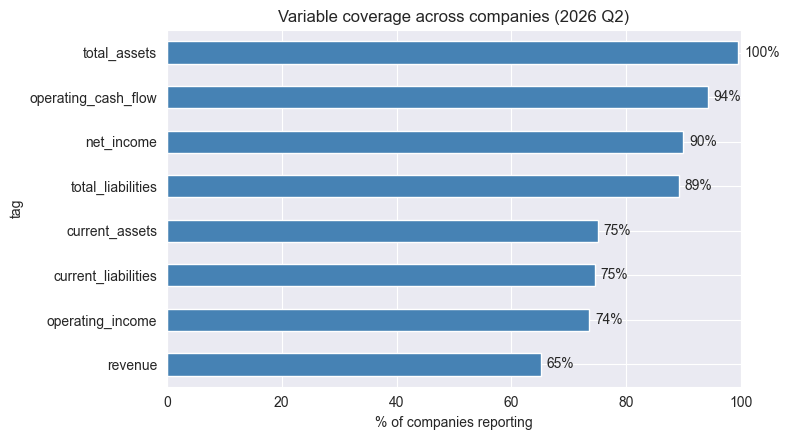

In [142]:
import matplotlib.pyplot as plt

#a company "reports" a variable if any of its rows has a value, then I take the % of companies
present = standardized[variable_cols].notna().copy()
present["cik"] = standardized["cik"].values
company_coverage = (present.groupby("cik").any().mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
company_coverage.plot(kind="barh", color="steelblue", ax=ax)
ax.set_xlabel("% of companies reporting")
ax.set_title("Variable coverage across companies (2026 Q2)")
ax.set_xlim(0, 100)
for i, v in enumerate(company_coverage):
    ax.text(v + 1, i, f"{v:.0f}%", va="center")
plt.tight_layout()
plt.show()

Looking At the 8-K Filings to Determine Bankruptcy Label

In [143]:
#We can see how many 8-K forms there are in total
sub[sub["form"] == "8-K"]

,adsh,cik,name,sic,countryba,stprba,cityba,zipba,bas1,bas2,...,period,fy,fp,filed,accepted,prevrpt,detail,instance,nciks,aciks
431,0000310764-26-000041,310764,STRYKER CORP,3841.0,US,MI,PORTAGE,49002,1941 STRYKER WAY,NaN,...,20251231.0,NaN,NaN,20260626,2026-06-26 15:46:00.0,0,1,syk-20260626_htm.xml,1,NaN
597,0000773840-26-000058,773840,HONEYWELL INTERNATIONAL INC,3724.0,US,NC,CHARLOTTE,28202,855 S. MINT STREET,NaN,...,20251231.0,NaN,NaN,20260423,2026-04-23 09:59:00.0,0,1,hon-20260423_d2_htm.xml,1,NaN
1223,0001095073-26-000027,1095073,"EVEREST GROUP, LTD.",6331.0,BM,NaN,HAMILTON,HM 19,"SEON PLACE, 4TH FLOOR",141 FRONT STREET,...,20251231.0,NaN,NaN,20260603,2026-06-03 09:17:00.0,0,1,eg-20260603_htm.xml,1,NaN
1804,0001104659-26-067497,4281,HOWMET AEROSPACE INC.,3350.0,US,PA,PITTSBURGH,15212-5872,201 ISABELLA STREET,SUITE 200,...,20251231.0,NaN,NaN,20260528,2026-05-28 16:12:00.0,0,1,hwm-20260528_htm.xml,1,NaN
2773,0001193125-26-214642,78128,"ESSENTIAL UTILITIES, INC.",4941.0,US,PA,BRYN MAWR,19010-3489,762 W. LANCASTER AVE,NaN,...,20260331.0,NaN,NaN,20260508,2026-05-08 16:12:00.0,0,1,d132698d8k_htm.xml,1,NaN
4595,0001437749-26-016373,729580,BEL FUSE INC /NJ,3677.0,US,NJ,WEST ORANGE,07052,300 EXECUTIVE DRIVE,SUITE 300,...,20251231.0,NaN,NaN,20260512,2026-05-12 14:25:00.0,0,1,belfa20260507_8k_htm.xml,1,NaN
5260,0001493152-26-022710,1853816,"DERMATA THERAPEUTICS, INC.",2834.0,US,CA,SAN DIEGO,92130,"3525 DEL MAR HEIGHTS RD., #322",NaN,...,20260331.0,NaN,NaN,20260513,2026-05-13 16:05:00.0,0,0,form8-k_htm.xml,1,NaN
6526,0001628280-26-040502,91576,KEYCORP /NEW/,6021.0,US,OH,CLEVELAND,44114-1306,127 PUBLIC SQ,NaN,...,20251231.0,NaN,NaN,20260603,2026-06-03 17:13:00.0,0,1,key-20260603_d2_htm.xml,1,NaN
6594,0001628280-26-044373,1428439,"ROKU, INC",4841.0,US,CA,SAN JOSE,95110,1173 COLEMAN AVENUE,NaN,...,20251231.0,NaN,NaN,20260618,2026-06-18 16:42:00.0,0,1,roku-20260618_htm.xml,1,NaN
7659,0002041610-26-000033,2041610,PARAMOUNT SKYDANCE CORP,4833.0,US,NY,NEW YORK,10036,1515 BROADWAY,NaN,...,20251231.0,NaN,NaN,20260513,2026-05-13 17:17:00.0,0,1,psky-20260513_d2_htm.xml,1,NaN


In [144]:
import requests

#sub[sub["form"] == "8-K"]
#adsh_test = "0000950103-26-008891", cik_test = "827187" for sleep number corporation, bankrupt on June 12 2026

#adsh_test = "0001493152-26-023162", cik_test = "1817511" for Society Pass Incorporated, bankrupt on May 12, 2026

#adsh_test = "0001753926-26-001173", cik_test = "1347242" for Lipella Pharmaceuticals, bankrupt on May 12, 2026

#So basically, we're using the cik and accession number to take a look at the filing EDGAR directory, which is associated with the specific filing, which would be 8-K in this case. -index.html page would be a table of contents for the filing basically. We access this via the response and beautiful soup combination.
adsh_test = "0001753926-26-001173"
cik_test = "1347242"
adsh_test_without_hyphens = adsh_test.replace("-", "")
#Url for the filing EDGAR directory associated with the specific file we're interested in
url = f"https://www.sec.gov/Archives/edgar/data/{cik_test}/{adsh_test_without_hyphens}/{adsh_test}-index.html"
#Direct link to the associated txt file for the filing
txt_url = f"https://www.sec.gov/Archives/edgar/data/{cik_test}/{adsh_test_without_hyphens}/{adsh_test}.txt"
#Direct link to the associated sgml file for the filing
sgml_url = f"https://www.sec.gov/Archives/edgar/data/{cik_test}/{adsh_test_without_hyphens}/{adsh_test}.hdr.sgml"
headers = {
    "User-Agent": "Kunal kdeb252@gmail.com"
}

response = requests.get(url, headers=headers)
response.status_code

200

In [145]:
from bs4 import BeautifulSoup
#Here, we look at the various document tables associated with the filing. We want the 8-K filing HTML, not just a summarization of the filing. This cell is exploring what tables are there so we can see which table we need to look into. Table 0 is what has all of the links we need, that's why there are so many htm and txt links in there
soup = BeautifulSoup(response.text, "html.parser")
tables = soup.find_all("table")
len(tables)
for i, table in enumerate(tables):
    print(f"TABLE{i}")
    print(table.get_text(" ", strip=True)[:1000])
    print("\n" + "-" * 80 + "\n")
#So now that we know table 0 is what we're looking at, we should see what is
#in each table row for table 0
for row in tables[0].find_all("tr"):
    print(row.get_text(" ", strip=True))

TABLE0
Seq Description Document Type Size 1 FORM 8-K g085807_8k.htm iXBRL 8-K 34718 2 EX-2.1 g085807_ex2-1.htm EX-2.1 101245 3 EX-2.2 g085807_ex2-2.htm EX-2.2 242621 4 GRAPHIC img001_v1.jpg GRAPHIC 10374 5 GRAPHIC img002_v1.jpg GRAPHIC 4657 Complete submission text file 0001753926-26-001173.txt 632008

--------------------------------------------------------------------------------

TABLE1
Seq Description Document Type Size 6 XBRL SCHEMA FILE lipo-20260612.xsd EX-101.SCH 2990 7 XBRL LABEL FILE lipo-20260612_lab.xml EX-101.LAB 34239 8 XBRL PRESENTATION FILE lipo-20260612_pre.xml EX-101.PRE 22342 18 EXTRACTED XBRL INSTANCE DOCUMENT g085807_8k_htm.xml XML 2880

--------------------------------------------------------------------------------

Seq Description Document Type Size
1 FORM 8-K g085807_8k.htm iXBRL 8-K 34718
2 EX-2.1 g085807_ex2-1.htm EX-2.1 101245
3 EX-2.2 g085807_ex2-2.htm EX-2.2 242621
4 GRAPHIC img001_v1.jpg GRAPHIC 10374
5 GRAPHIC img002_v1.jpg GRAPHIC 4657
Complete submissi

In [146]:
#Now we're looking at the part in the table that is associated with the 8-K form
row1 = tables[0].find_all("tr")[1]
#a1 = row1.find_all("a")[0]
#print(a1)
#print(a1.get_text(strip=True))
#print(a1.get("href"))
first_part_of_link = "https://www.sec.gov"
#We're looking for any links in the table row, there is only one which is what we want
#We then have to get rid of the first 7 characters and append the rest to the first part of the link
#This is the full link for the 8-K filing.
for a in row1.find_all("a"):
    href = a.get("href")
    print(href)
    second_part_of_link = href[8:]
    full_link = first_part_of_link + second_part_of_link
    print(full_link)
#I'm printing the link to the text file and sgml file for the corresponding 8-K filing for so it's all in one place
    print(txt_url)
    print(sgml_url)

/ix?doc=/Archives/edgar/data/1347242/000175392626001173/g085807_8k.htm
https://www.sec.gov/Archives/edgar/data/1347242/000175392626001173/g085807_8k.htm
https://www.sec.gov/Archives/edgar/data/1347242/000175392626001173/0001753926-26-001173.txt
https://www.sec.gov/Archives/edgar/data/1347242/000175392626001173/0001753926-26-001173.hdr.sgml


In [147]:
#So now we're using response and soup on the 8-K filing itself and the sgml file
eight_k_response = requests.get(full_link, headers=headers)
eight_k_sgml = requests.get(sgml_url, headers=headers)
print(eight_k_response.status_code)
print(eight_k_sgml.status_code)



200
200


In [148]:
import re
#The whole point of this cell is to isolate the acceptance date and filing date
acceptancedatetimeline = []
filingdatetimeline = []
for line in eight_k_sgml.text.split("\n"):
    if "DATETIME" in line:
        acceptancedatetimeline.append(line.strip())
    if "FILING" in line and "DATE" in line:
        filingdatetimeline.append(line.strip())
    print(line)
print(acceptancedatetimeline)
print(filingdatetimeline)

#I'm using re to get rid of anything that isn't a digit for the first value in each list
acceptancedate = re.sub(r'\D', '', acceptancedatetimeline[0])

filingdate = re.sub(r'\D', '', filingdatetimeline[0])

print(acceptancedate)
print(filingdate)

<SEC-HEADER>0001753926-26-001173.hdr.sgml : 20260715
<ACCEPTANCE-DATETIME>20260715103808
<ACCESSION-NUMBER>0001753926-26-001173
<TYPE>8-K
<PUBLIC-DOCUMENT-COUNT>15
<PERIOD>20260612
<ITEMS>1.03
<ITEMS>9.01
<FILING-DATE>20260715
<DATE-OF-FILING-DATE-CHANGE>20260715
<FILER>
<COMPANY-DATA>
<CONFORMED-NAME>LIPELLA PHARMACEUTICALS INC.
<CIK>0001347242
<ASSIGNED-SIC>2834
<ORGANIZATION-NAME>03 Life Sciences
<IRS-NUMBER>000000000
<STATE-OF-INCORPORATION>DE
<FISCAL-YEAR-END>1231
</COMPANY-DATA>
<FILING-VALUES>
<FORM-TYPE>8-K
<ACT>34
<FILE-NUMBER>001-41575
<FILM-NUMBER>261176359
</FILING-VALUES>
<BUSINESS-ADDRESS>
<STREET1>400 N LEXINGTON ST
<STREET2>STE LL103
<CITY>PITTSBURGH
<STATE>PA
<ZIP>15208
<PHONE>412-901-0315
</BUSINESS-ADDRESS>
<MAIL-ADDRESS>
<STREET1>400 N LEXINGTON ST
<STREET2>STE LL103
<CITY>PITTSBURGH
<STATE>PA
<ZIP>15208
</MAIL-ADDRESS>
<FORMER-COMPANY>
<FORMER-CONFORMED-NAME>LIPELLA PHARMACEUTICALS INC
<DATE-CHANGED>20051219
</FORMER-COMPANY>
</FILER>
</SEC-HEADER>

['<ACCEPTANCE-D

In [149]:
#I'm printing out a sample of the html for the 8-K filing so I can see what is going on
print(eight_k_response.text[:100000])

<?xml version='1.0' encoding='ASCII'?>
<html xmlns="http://www.w3.org/1999/xhtml" xmlns:xs="http://www.w3.org/2001/XMLSchema-instance" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns:xbrli="http://www.xbrl.org/2003/instance" xmlns:xbrldi="http://xbrl.org/2006/xbrldi" xmlns:xbrldt="http://xbrl.org/2005/xbrldt" xmlns:iso4217="http://www.xbrl.org/2003/iso4217" xmlns:ix="http://www.xbrl.org/2013/inlineXBRL" xmlns:ixt="http://www.xbrl.org/inlineXBRL/transformation/2015-02-26" xmlns:ixt-sec="http://www.sec.gov/inlineXBRL/transformation/2015-08-31" xmlns:link="http://www.xbrl.org/2003/linkbase" xmlns:dei="http://xbrl.sec.gov/dei/2026" xmlns:us-gaap="http://fasb.org/us-gaap/2026" xmlns:us-roles="http://fasb.org/us-roles/2026" xmlns:country="http://xbrl.sec.gov/country/2026" xmlns:srt="http://fasb.org/srt/2026" xmlns:LIPO="http://LIPO/20260612">
<head>
     <title></title>
<meta http-equiv="Content-Type" content="text/html"/>
</head>
<!-- Field: Set; Name: xdx; ID: xdx_02F_US%2DGAAP%2D2026 -->

In [150]:
#Now we're using beautifulsoup to go through the 8-K html
document_soup = BeautifulSoup(eight_k_response.text, "html.parser")

In [151]:
#Documentation: https://beautiful-soup-4.readthedocs.io/en/latest/#searching-the-tree

#So here, I'm looking at every bold title in the 8-K filing to see if I can isolate item 1.03 somehow
#I realize that Item 1.03 in bold is consistent for marking the start of the section, and that
#The section ends at the next bold title that has the term "item" in it
marker = 0
for b in document_soup.find_all("b"):
    print(b.get_text(" ", strip=True))
    text = b.get_text(" ", strip=True)
    if marker == 1:
        if "Item" in text:
            ending_header = b
    if "1.03" in text:
        #print(repr(text))
        starting_header = b
        marker = 1

print(starting_header)
print(ending_header)

UNITED
STATES SECURITIES AND EXCHANGE COMMISSION Washington, D.C. 20549
FORM 8-K
CURRENT
REPORT
Pursuant to Section 13 or 15(d) of the Securities Exchange Act of 1934
Date
of Report (Date of earliest event reported): June 12, 2026
Lipella
Pharmaceuticals Inc.
(Exact name of registrant as specified in its charter)
1159
S. Negley Avenue , Pittsburgh , PA 15217
(Address of principal executive offices) (Zip Code)
( 412 ) 894-1853
(Registrant's telephone number, including area code)
Item
1.01    Entry into a Material Definitive Agreement
Item
1.03    Bankruptcy or Receivership.
Cautionary
Note Regarding the Company’s Common Stock
Item
9.01    Financial Statements and Exhibits.
(d)
Exhibits
Exhibit
Number
Description
SIGNATURE
<b>Item
1.03    Bankruptcy or Receivership.</b>
<b>Item
9.01    Financial Statements and Exhibits.</b>


In [152]:
#https://beautiful-soup-4.readthedocs.io/en/latest/
#So here, I figured out that I could use soup.strings to get what we need. So now, we have
#every string in the bankruptcy section
marker2 = 0
listofrelevanttexts = []
for string in document_soup.strings:
    if marker2 == 1 and "Item" not in string:
        listofrelevanttexts.append(string)

    if marker2 == 1 and "Item" in string:
        marker2 = 0

    if "1.03" in string and "Bankruptcy" in string:
        marker2 = 1

    #print(repr(string))
#For the list, I still have to get rid of anything that is only three characters long, and get rid o that annoying \stuff
print(listofrelevanttexts)

['\n', '\xa0', '\n', 'Asset\nPurchase Agreement', '\n', '\xa0', '\n', 'On\nMarch 30, 2026, Lipella Pharmaceuticals Inc. (the “Company”) filed a voluntary petition for relief under chapter 11\nof title 11 of the United States Code in the United States Bankruptcy Court for the Western District of Pennsylvania (the “Bankruptcy\nCourt”) at Case No. 26-20879-CMB (the “Bankruptcy Case”).', '\n', '\xa0', '\n', 'On\nMay 14, 2026, the Company entered into an Asset Purchase Agreement (the “Asset Purchase Agreement”) with XRAIY (the\n“Purchaser”) pursuant to which the Purchaser agreed to purchase substantially all of the assets of the Company (such\nassets, the “Purchased Assets,” and such transaction, the “Sale”). The Bankruptcy Court authorized and\napproved the Sale and the Asset Purchase Agreement, pursuant to section 363 of the Bankruptcy Code, by Order dated June 4, 2026,\nat Doc. No. 115 (the “Sale Order”).', '\n', '\xa0', '\n', 'A\ncopy of the Sale Order is attached hereto as ', 'Exhibit 

Putting All Of the Code Together To Make a Dataframe

In [153]:
print(standardized_current)

          cik                  adsh                             name  \
0        1800  0001628280-26-028357              ABBOTT LABORATORIES   
1        1961  0000001961-26-000014                      GEMAXEL INC   
2        1961  0000001961-26-000025                      GEMAXEL INC   
3        1961  0000001961-26-000030                      GEMAXEL INC   
4        2098  0001193125-26-209010                 ACME UNITED CORP   
...       ...                   ...                              ...   
6950  2115404  0001213900-26-067939  COLLECTIVE ACQUISITION CORP. II   
6951  2123969  0001193125-26-236857   RRE VENTURES ACQUISITION CORP.   
6952  2131882  0001683168-26-004950            MCCARTHY FINNEY, INC.   
6953  2137360  0001520138-26-000188                       YOUMI INC.   
6954  2137360  0001520138-26-000256                       YOUMI INC.   

         ddate  total_assets  current_assets  current_liabilities  \
0     20260331  1.104290e+11    2.550800e+10         1.837700e+10 

In [154]:
column_names = ['cik', 'adsh', 'Bankruptcy', 'Filingdate', 'Acceptancedate', 'listoftext']

labeling_df = pd.DataFrame(columns = column_names)

def create_label_values(cik, adsh, df):
    adsh_method_test = adsh
    cik_method_test = cik
    adsh_method_test_without_hyphens = adsh_test.replace("-", "")
    #Url for the filing EDGAR directory associated with the specific file we're interested in
    method_url = f"https://www.sec.gov/Archives/edgar/data/{cik_method_test}/{adsh_method_test_without_hyphens}/{adsh_method_test}-index.html"
    method_sgml_url = f"https://www.sec.gov/Archives/edgar/data/{cik_test}/{adsh_test_without_hyphens}/{adsh_test}.hdr.sgml"
    name = "Kunal"
    email = "kdeb252@gmail.com"
    headers_method = {
    "User-Agent": f"{name} {email}"
    }

    index_response = requests.get(method_url, headers=headers_method)
    #response.status_code
    if "8-K" in index_response.text:
        soup_filing = BeautifulSoup(response.text, "html.parser")
        tables_filing = soup_filing.find_all("table")
        row1 = tables_filing[0].find_all("tr")[1]
        for a in row1.find_all("a"):
            href = a.get("href")
            #print(href)
            first_part_of_link = "https://www.sec.gov"
            second_part_of_link = href[8:]
            full_link = first_part_of_link + second_part_of_link
        eight_k_response = requests.get(full_link, headers=headers)
        eight_k_sgml = requests.get(sgml_url, headers=headers)
        acceptancedatetimeline = []
        filingdatetimeline = []
        for line in eight_k_sgml.text.split("\n"):
            if "DATETIME" in line:
                acceptancedatetimeline.append(line.strip())
            if "FILING" in line and "DATE" in line:
                filingdatetimeline.append(line.strip())
        #I'm using re to get rid of anything that isn't a digit for the first value in each list
        acceptancedate = re.sub(r'\D', '', acceptancedatetimeline[0])
        filingdate = re.sub(r'\D', '', filingdatetimeline[0])
        document_soup = BeautifulSoup(eight_k_response.text, "html.parser")
        marker2 = 0
        listofrelevanttexts = []
        for string in document_soup.strings:
            if marker2 == 1 and "Item" not in string:
                listofrelevanttexts.append(string)
            if marker2 == 1 and "Item" in string:
                marker2 = 0
            if "1.03" in string and "Bankruptcy" in string:
                marker2 = 1
        if len(listofrelevanttexts) != 0:
            Bankruptcy = 1
        else:
            Bankruptcy = 0
        list_to_add_to_dataframe = [cik_method_test, adsh_method_test, Bankruptcy, filingdate, acceptancedate, listofrelevanttexts]
        df.loc[len(df)] = list_to_add_to_dataframe

    else:
        Bankruptcy = 0
        Filingdate = "Not Applicable"
        Acceptancedate = "Not Applicable"
        listoftext = ["Not Applicable"]
        list_to_add_to_dataframe = [cik_method_test, adsh_method_test, Bankruptcy, Filingdate, Acceptancedate, listoftext]
        df.loc[len(df)] = list_to_add_to_dataframe

In [155]:
display(labeling_df)

,cik,adsh,Bankruptcy,Filingdate,Acceptancedate,listoftext


In [156]:
#For 21 thousand rows, this took about 2 hours and 26 minutes
#I did this a second time and it took 3 hours and 38 minutes
for cik, adsh in zip(standardized_current['cik'], standardized_current['adsh']):
    create_label_values(cik, adsh, labeling_df)
display(labeling_df)

,cik,adsh,Bankruptcy,Filingdate,Acceptancedate,listoftext
0,1800,0001628280-26-028357,0,Not Applicable,Not Applicable,[Not Applicable]
1,1961,0000001961-26-000014,0,Not Applicable,Not Applicable,[Not Applicable]
2,1961,0000001961-26-000025,0,Not Applicable,Not Applicable,[Not Applicable]
3,1961,0000001961-26-000030,0,Not Applicable,Not Applicable,[Not Applicable]
4,2098,0001193125-26-209010,0,Not Applicable,Not Applicable,[Not Applicable]
...,...,...,...,...,...,...
6950,2115404,0001213900-26-067939,0,Not Applicable,Not Applicable,[Not Applicable]
6951,2123969,0001193125-26-236857,0,Not Applicable,Not Applicable,[Not Applicable]
6952,2131882,0001683168-26-004950,0,Not Applicable,Not Applicable,[Not Applicable]
6953,2137360,0001520138-26-000188,0,Not Applicable,Not Applicable,[Not Applicable]


In [161]:
merged_standardized_df = pd.merge(standardized_current, labeling_df, on=['cik', 'adsh'], how='inner')
display(merged_standardized_df)

,cik,adsh,name,ddate,total_assets,current_assets,current_liabilities,total_liabilities,revenue,net_income,operating_income,operating_cash_flow,Bankruptcy,Filingdate,Acceptancedate,listoftext
0,1800,0001628280-26-028357,ABBOTT LABORATORIES,20260331,1.104290e+11,2.550800e+10,1.837700e+10,NaN,1.116400e+10,1.077000e+09,1.345000e+09,1.315000e+09,0,Not Applicable,Not Applicable,[Not Applicable]
1,1961,0000001961-26-000014,GEMAXEL INC,20250331,9.959000e+03,9.959000e+03,3.780105e+06,3780105.0,NaN,-1.166010e+05,-9.786300e+04,-7.484000e+03,0,Not Applicable,Not Applicable,[Not Applicable]
2,1961,0000001961-26-000025,GEMAXEL INC,20250630,9.004000e+03,9.004000e+03,3.918217e+06,3918217.0,NaN,-1.390670e+05,-1.196780e+05,-6.336100e+04,0,Not Applicable,Not Applicable,[Not Applicable]
3,1961,0000001961-26-000030,GEMAXEL INC,20250930,6.817000e+03,6.817000e+03,3.981384e+06,3981384.0,NaN,-6.535500e+04,-4.514200e+04,-6.336100e+04,0,Not Applicable,Not Applicable,[Not Applicable]
4,2098,0001193125-26-209010,ACME UNITED CORP,20260331,1.952430e+08,1.056110e+08,2.310400e+07,78516000.0,5.230100e+07,9.850000e+05,1.746000e+06,-2.233000e+06,0,Not Applicable,Not Applicable,[Not Applicable]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6950,2115404,0001213900-26-067939,COLLECTIVE ACQUISITION CORP. II,20260331,3.684640e+05,2.500000e+04,3.681770e+05,368177.0,NaN,-2.471300e+04,-2.471300e+04,NaN,0,Not Applicable,Not Applicable,[Not Applicable]
6951,2123969,0001193125-26-236857,RRE VENTURES ACQUISITION CORP.,20260331,4.564070e+05,3.117000e+03,4.721590e+05,491418.0,NaN,-6.001100e+04,-6.001100e+04,0.000000e+00,0,Not Applicable,Not Applicable,[Not Applicable]
6952,2131882,0001683168-26-004950,"MCCARTHY FINNEY, INC.",20260331,3.499628e+06,1.516691e+06,6.585960e+05,662254.0,0.000000e+00,-2.281553e+06,-2.288454e+06,-2.275114e+06,0,Not Applicable,Not Applicable,[Not Applicable]
6953,2137360,0001520138-26-000188,YOUMI INC.,20260430,2.025080e+05,2.025080e+05,7.000000e+04,70000.0,0.000000e+00,-9.060000e+02,-9.060000e+02,-9.060000e+02,0,Not Applicable,Not Applicable,[Not Applicable]


In [162]:
(merged_standardized_df["Bankruptcy"] == 1).sum()

np.int64(12)

In [163]:
(merged_standardized_df["Bankruptcy"] == 0).sum()

np.int64(6943)

In [166]:
merged_standardized_df.to_csv('merged_standardized_df.txt', sep='\t', index=False)